In [5]:
from neo4j import GraphDatabase
from dotenv import load_dotenv
import os
load_dotenv()

True

In [16]:
class Neo4jConnection:
    def __init__(self, uri: str, user: str, password: str):
        self._driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        self._driver.close()

    def get_driver(self):
        return self._driver

def test_connection(driver):
    with driver.session() as session:
        result = session.run("RETURN 'Conectado a Neo4j' AS mensaje")
        for record in result:
            print(record["mensaje"])

# Configuración inicial
URI = os.getenv("NEO4J_URI")
USER = os.getenv("NEO4J_USERNAME")
PASSWORD = os.getenv("NEO4J_PASSWORD")

try:
    conn = Neo4jConnection(URI, USER, PASSWORD)
    driver = conn.get_driver()
    test_connection(driver)
except Exception as e:
    print(f"Error al conectar: {e}")

Conectado a Neo4j


Preparación de Restricciones y Funciones de Utilidad
Configuración de restricciones de unicidad y función para lectura de CSV.

In [7]:
import csv

def create_constraints(driver):
    queries = [
        "CREATE CONSTRAINT IF NOT EXISTS FOR (n:User) REQUIRE n.user_id IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Artist) REQUIRE n.artist_id IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Song) REQUIRE n.song_id IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Genre) REQUIRE n.genre_id IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Playlist) REQUIRE n.playlist_id IS UNIQUE",
        "CREATE CONSTRAINT IF NOT EXISTS FOR (n:Post) REQUIRE n.post_id IS UNIQUE"
    ]
    with driver.session() as session:
        for q in queries:
            session.run(q)
    print("Restricciones de unicidad creadas o verificadas.")

def load_csv_to_list(file_path):
    with open(file_path, mode='r', encoding='utf-8') as f:
        return list(csv.DictReader(f))

create_constraints(driver)

Restricciones de unicidad creadas o verificadas.


Carga de Nodos - Entidades Independientes
Carga individual de Genre, Artist y User con impresion de evidencia.

In [8]:
def load_genres(driver):
    data = load_csv_to_list('data/genres.csv')
    query = """
    MERGE (g:Genre {genre_id: $genre_id})
    SET g.nombre = $nombre,
        g.descripcion = $descripcion,
        g.popularidad = toInteger($popularidad),
        g.origen = $origen,
        g.activo = toBoolean($activo)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Nodo Genre cargado: ID {row['genre_id']} - {row['nombre']}")
    print(f"Carga de Genres finalizada ({len(data)} registros)")

def load_artists(driver):
    data = load_csv_to_list('data/artists.csv')
    query = """
    MERGE (a:Artist {artist_id: $artist_id})
    SET a.nombre = $nombre,
        a.pais = $pais,
        a.genero_principal = $genero_principal,
        a.activo = toBoolean($activo),
        a.anios_activo = toInteger($anios_activo)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Nodo Artist cargado: ID {row['artist_id']} - {row['nombre']}")
    print(f"Carga de Artists finalizada ({len(data)} registros)")

load_genres(driver)
load_artists(driver)

Nodo Genre cargado: ID 1 - rock
Nodo Genre cargado: ID 2 - electronic
Nodo Genre cargado: ID 3 - rock
Nodo Genre cargado: ID 4 - rock
Nodo Genre cargado: ID 5 - electronic
Nodo Genre cargado: ID 6 - pop
Nodo Genre cargado: ID 7 - hiphop
Nodo Genre cargado: ID 8 - jazz
Nodo Genre cargado: ID 9 - hiphop
Nodo Genre cargado: ID 10 - jazz
Nodo Genre cargado: ID 11 - hiphop
Nodo Genre cargado: ID 12 - electronic
Nodo Genre cargado: ID 13 - rock
Nodo Genre cargado: ID 14 - pop
Nodo Genre cargado: ID 15 - rock
Nodo Genre cargado: ID 16 - hiphop
Nodo Genre cargado: ID 17 - electronic
Nodo Genre cargado: ID 18 - latin
Nodo Genre cargado: ID 19 - pop
Nodo Genre cargado: ID 20 - pop
Nodo Genre cargado: ID 21 - jazz
Nodo Genre cargado: ID 22 - rock
Nodo Genre cargado: ID 23 - hiphop
Nodo Genre cargado: ID 24 - hiphop
Nodo Genre cargado: ID 25 - electronic
Nodo Genre cargado: ID 26 - hiphop
Nodo Genre cargado: ID 27 - electronic
Nodo Genre cargado: ID 28 - rock
Nodo Genre cargado: ID 29 - rock
Nodo 

In [9]:
def load_users(driver):
    data = load_csv_to_list('data/users.csv')
    query = """
    MERGE (u:User {user_id: $user_id})
    SET u.username = $username,
        u.email = $email,
        u.fecha_registro = date($fecha_registro),
        u.premium = toBoolean($premium),
        u.generos_favoritos = split($generos, ",")
    WITH u
    WHERE toBoolean($es_artista) = true
    SET u:Artist
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Nodo User cargado: ID {row['user_id']} - {row['username']} (Es artista: {row['es_artista']})")
    print(f"Carga de Users finalizada ({len(data)} registros)")

load_users(driver)

Nodo User cargado: ID 1 - hannahhahn (Es artista: False)
Nodo User cargado: ID 2 - xgarcia (Es artista: False)
Nodo User cargado: ID 3 - lisathompson (Es artista: False)
Nodo User cargado: ID 4 - rebecca35 (Es artista: False)
Nodo User cargado: ID 5 - matthewmolina (Es artista: False)
Nodo User cargado: ID 6 - jamessmith (Es artista: False)
Nodo User cargado: ID 7 - meganenglish (Es artista: False)
Nodo User cargado: ID 8 - charles01 (Es artista: False)
Nodo User cargado: ID 9 - vmann (Es artista: False)
Nodo User cargado: ID 10 - gonzalezdalton (Es artista: False)
Nodo User cargado: ID 11 - carrieparker (Es artista: False)
Nodo User cargado: ID 12 - cole24 (Es artista: False)
Nodo User cargado: ID 13 - jhernandez (Es artista: False)
Nodo User cargado: ID 14 - cartersteven (Es artista: False)
Nodo User cargado: ID 15 - thopkins (Es artista: False)
Nodo User cargado: ID 16 - deannamiller (Es artista: True)
Nodo User cargado: ID 17 - rvelasquez (Es artista: False)
Nodo User cargado: ID 1

Carga de Nodos - Entidades Dependientes
Carga individual de Song, Playlist y Post con impresion de evidencia.

In [10]:
def load_songs(driver):
    data = load_csv_to_list('data/songs.csv')
    query = """
    MERGE (s:Song {song_id: $song_id})
    SET s.titulo = $titulo,
        s.duracion = toFloat($duracion),
        s.fecha_lanzamiento = date($fecha_lanzamiento),
        s.popularidad = toInteger($popularidad),
        s.idiomas = split($idiomas, ",")
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Nodo Song cargado: ID {row['song_id']} - {row['titulo']}")
    print(f"Carga de Songs finalizada ({len(data)} registros)")

def load_playlists(driver):
    data = load_csv_to_list('data/playlists.csv')
    query = """
    MERGE (p:Playlist {playlist_id: $playlist_id})
    SET p.nombre = $nombre,
        p.descripcion = $descripcion,
        p.fecha_creacion = date($fecha_creacion),
        p.publica = toBoolean($publica),
        p.numero_canciones = toInteger($numero_canciones)
    WITH p
    WHERE toBoolean($destacada) = true
    SET p:Featured
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Nodo Playlist cargado: ID {row['playlist_id']} - {row['nombre']} (Destacada: {row['destacada']})")
    print(f"Carga de Playlists finalizada ({len(data)} registros)")

def load_posts(driver):
    data = load_csv_to_list('data/posts.csv')
    query = """
    MERGE (p:Post {post_id: $post_id})
    SET p.caption = $caption,
        p.fecha = date($fecha),
        p.tipo = $tipo,
        p.privacidad = $privacidad,
        p.hashtags = split($hashtags, ",")
    WITH p
    WHERE toBoolean($promocionado) = true
    SET p:Ad
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Nodo Post cargado: ID {row['post_id']} - {row['tipo']} (Promocionado: {row['promocionado']})")
    print(f"Carga de Posts finalizada ({len(data)} registros)")

load_songs(driver)
load_playlists(driver)
load_posts(driver)

Nodo Song cargado: ID 1 - old
Nodo Song cargado: ID 2 - race
Nodo Song cargado: ID 3 - push
Nodo Song cargado: ID 4 - if
Nodo Song cargado: ID 5 - network
Nodo Song cargado: ID 6 - sometimes
Nodo Song cargado: ID 7 - pattern
Nodo Song cargado: ID 8 - past
Nodo Song cargado: ID 9 - free
Nodo Song cargado: ID 10 - agree
Nodo Song cargado: ID 11 - factor
Nodo Song cargado: ID 12 - behavior
Nodo Song cargado: ID 13 - popular
Nodo Song cargado: ID 14 - nation
Nodo Song cargado: ID 15 - dream
Nodo Song cargado: ID 16 - until
Nodo Song cargado: ID 17 - including
Nodo Song cargado: ID 18 - evening
Nodo Song cargado: ID 19 - dinner
Nodo Song cargado: ID 20 - fund
Nodo Song cargado: ID 21 - always
Nodo Song cargado: ID 22 - former
Nodo Song cargado: ID 23 - total
Nodo Song cargado: ID 24 - particular
Nodo Song cargado: ID 25 - between
Nodo Song cargado: ID 26 - federal
Nodo Song cargado: ID 27 - five
Nodo Song cargado: ID 28 - source
Nodo Song cargado: ID 29 - ahead
Nodo Song cargado: ID 30 - ad

Carga de Relaciones - Estructurales
Conexiones Song-Artist, Song-Genre, User-Post y User-Playlist.

In [11]:
def load_rel_by(driver):
    data = load_csv_to_list('data/song_artist.csv')
    query = """
    MATCH (s:Song {song_id: $song_id})
    MATCH (a:Artist {artist_id: $artist_id})
    MERGE (s)-[r:BY]->(a)
    SET r.rol = $rol,
        r.fecha_colaboracion = date($fecha_colaboracion),
        r.principal = toBoolean($principal)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion BY cargada: Song {row['song_id']} -> Artist {row['artist_id']}")
    print(f"Carga de relaciones BY finalizada ({len(data)} registros)")

def load_rel_belongs(driver):
    data = load_csv_to_list('data/song_genre.csv')
    query = """
    MATCH (s:Song {song_id: $song_id})
    MATCH (g:Genre {genre_id: $genre_id})
    MERGE (s)-[r:BELONGS_TO]->(g)
    SET r.relevancia = toFloat($relevancia),
        r.fecha_asignacion = date($fecha_asignacion),
        r.principal = toBoolean($principal)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion BELONGS_TO cargada: Song {row['song_id']} -> Genre {row['genre_id']}")
    print(f"Carga de relaciones BELONGS_TO finalizada ({len(data)} registros)")

def load_rel_created_post(driver):
    data = load_csv_to_list('data/created_posts.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (p:Post {post_id: $post_id})
    MERGE (u)-[r:CREATED]->(p)
    SET r.fecha_creacion = date($fecha_creacion),
        r.dispositivo = $dispositivo,
        r.ubicacion = $ubicacion
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion CREATED (Post) cargada: User {row['user_id']} -> Post {row['post_id']}")
    print(f"Carga de relaciones CREATED finalizada ({len(data)} registros)")

def load_rel_created_playlist(driver):
    data = load_csv_to_list('data/created_playlists.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (p:Playlist {playlist_id: $playlist_id})
    MERGE (u)-[r:CREATED_PLAYLIST]->(p)
    SET r.fecha = date($fecha),
        r.colaborativa = toBoolean($colaborativa),
        r.numero_ediciones = toInteger($numero_ediciones)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion CREATED_PLAYLIST cargada: User {row['user_id']} -> Playlist {row['playlist_id']}")
    print(f"Carga de relaciones CREATED_PLAYLIST finalizada ({len(data)} registros)")

load_rel_by(driver)
load_rel_belongs(driver)
load_rel_created_post(driver)
load_rel_created_playlist(driver)

Relacion BY cargada: Song 1 -> Artist 336
Relacion BY cargada: Song 1 -> Artist 38
Relacion BY cargada: Song 2 -> Artist 9
Relacion BY cargada: Song 3 -> Artist 453
Relacion BY cargada: Song 4 -> Artist 61
Relacion BY cargada: Song 4 -> Artist 416
Relacion BY cargada: Song 5 -> Artist 70
Relacion BY cargada: Song 5 -> Artist 363
Relacion BY cargada: Song 6 -> Artist 128
Relacion BY cargada: Song 7 -> Artist 310
Relacion BY cargada: Song 8 -> Artist 151
Relacion BY cargada: Song 8 -> Artist 17
Relacion BY cargada: Song 9 -> Artist 41
Relacion BY cargada: Song 9 -> Artist 66
Relacion BY cargada: Song 10 -> Artist 438
Relacion BY cargada: Song 11 -> Artist 191
Relacion BY cargada: Song 12 -> Artist 404
Relacion BY cargada: Song 13 -> Artist 221
Relacion BY cargada: Song 14 -> Artist 274
Relacion BY cargada: Song 15 -> Artist 442
Relacion BY cargada: Song 16 -> Artist 47
Relacion BY cargada: Song 17 -> Artist 124
Relacion BY cargada: Song 18 -> Artist 96
Relacion BY cargada: Song 19 -> Art

Carga de Relaciones - Contenido
Conexiones Post-Song y Playlist-Song.

In [12]:
def load_rel_contains(driver):
    data = load_csv_to_list('data/post_songs.csv')
    query = """
    MATCH (p:Post {post_id: $post_id})
    MATCH (s:Song {song_id: $song_id})
    MERGE (p)-[r:CONTAINS]->(s)
    SET r.orden = toInteger($orden),
        r.destacado = toBoolean($destacado),
        r.timestamp = toFloat($timestamp)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion CONTAINS cargada: Post {row['post_id']} -> Song {row['song_id']}")
    print(f"Carga de relaciones CONTAINS finalizada ({len(data)} registros)")

def load_rel_includes(driver):
    data = load_csv_to_list('data/playlist_songs.csv')
    query = """
    MATCH (p:Playlist {playlist_id: $playlist_id})
    MATCH (s:Song {song_id: $song_id})
    MERGE (p)-[r:INCLUDES]->(s)
    SET r.fecha_agregado = date($fecha_agregado),
        r.orden = toInteger($orden),
        r.favorito = toBoolean($favorito)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion INCLUDES cargada: Playlist {row['playlist_id']} -> Song {row['song_id']}")
    print(f"Carga de relaciones INCLUDES finalizada ({len(data)} registros)")

load_rel_contains(driver)
load_rel_includes(driver)

Relacion CONTAINS cargada: Post 1 -> Song 704
Relacion CONTAINS cargada: Post 2 -> Song 1181
Relacion CONTAINS cargada: Post 3 -> Song 55
Relacion CONTAINS cargada: Post 4 -> Song 164
Relacion CONTAINS cargada: Post 5 -> Song 749
Relacion CONTAINS cargada: Post 6 -> Song 653
Relacion CONTAINS cargada: Post 7 -> Song 616
Relacion CONTAINS cargada: Post 8 -> Song 1045
Relacion CONTAINS cargada: Post 9 -> Song 764
Relacion CONTAINS cargada: Post 10 -> Song 1419
Relacion CONTAINS cargada: Post 11 -> Song 63
Relacion CONTAINS cargada: Post 12 -> Song 1110
Relacion CONTAINS cargada: Post 13 -> Song 808
Relacion CONTAINS cargada: Post 14 -> Song 1103
Relacion CONTAINS cargada: Post 15 -> Song 446
Relacion CONTAINS cargada: Post 16 -> Song 973
Relacion CONTAINS cargada: Post 17 -> Song 503
Relacion CONTAINS cargada: Post 18 -> Song 55
Relacion CONTAINS cargada: Post 19 -> Song 1081
Relacion CONTAINS cargada: Post 20 -> Song 186
Relacion CONTAINS cargada: Post 21 -> Song 414
Relacion CONTAINS c

Carga de Relaciones - Interacción y Social
Conexiones Follows, Liked, Commented, Listened, Follows_Artist y Saved.

In [13]:
def load_rel_follows(driver):
    data = load_csv_to_list('data/follows.csv')
    query = """
    MATCH (u1:User {user_id: $user1})
    MATCH (u2:User {user_id: $user2})
    MERGE (u1)-[r:FOLLOWS]->(u2)
    SET r.fecha = date($fecha),
        r.notificaciones = toBoolean($notificaciones),
        r.cercania = toFloat($cercania)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion FOLLOWS cargada: User {row['user1']} -> User {row['user2']}")
    print(f"Carga de relaciones FOLLOWS finalizada ({len(data)} registros)")

def load_rel_liked(driver):
    data = load_csv_to_list('data/liked.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (p:Post {post_id: $post_id})
    MERGE (u)-[r:LIKED]->(p)
    SET r.fecha = date($fecha),
        r.reaccion = $reaccion,
        r.intensidad = toInteger($intensidad)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion LIKED cargada: User {row['user_id']} -> Post {row['post_id']}")
    print(f"Carga de relaciones LIKED finalizada ({len(data)} registros)")

def load_rel_commented(driver):
    data = load_csv_to_list('data/commented.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (p:Post {post_id: $post_id})
    MERGE (u)-[r:COMMENTED]->(p)
    SET r.fecha = date($fecha),
        r.contenido = $contenido,
        r.likes = toInteger($likes)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion COMMENTED cargada: User {row['user_id']} -> Post {row['post_id']}")
    print(f"Carga de relaciones COMMENTED finalizada ({len(data)} registros)")

def load_rel_listened(driver):
    data = load_csv_to_list('data/listened.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (s:Song {song_id: $song_id})
    MERGE (u)-[r:LISTENED]->(s)
    SET r.fecha = date($fecha),
        r.duracion_escuchada = toFloat($duracion_escuchada),
        r.completado = toBoolean($completado)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion LISTENED cargada: User {row['user_id']} -> Song {row['song_id']}")
    print(f"Carga de relaciones LISTENED finalizada ({len(data)} registros)")

def load_rel_follows_artist(driver):
    data = load_csv_to_list('data/follows_artist.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (a:Artist {artist_id: $artist_id})
    MERGE (u)-[r:FOLLOWS_ARTIST]->(a)
    SET r.fecha = date($fecha),
        r.notificaciones = toBoolean($notificaciones),
        r.interacciones = toInteger($interacciones)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion FOLLOWS_ARTIST cargada: User {row['user_id']} -> Artist {row['artist_id']}")
    print(f"Carga de relaciones FOLLOWS_ARTIST finalizada ({len(data)} registros)")

def load_rel_saved(driver):
    data = load_csv_to_list('data/saved_playlists.csv')
    query = """
    MATCH (u:User {user_id: $user_id})
    MATCH (p:Playlist {playlist_id: $playlist_id})
    MERGE (u)-[r:SAVED]->(p)
    SET r.fecha = date($fecha),
        r.veces_reproducida = toInteger($veces_reproducida),
        r.favorita = toBoolean($favorita)
    """
    with driver.session() as session:
        for row in data:
            session.run(query, **row)
            print(f"Relacion SAVED cargada: User {row['user_id']} -> Playlist {row['playlist_id']}")
    print(f"Carga de relaciones SAVED finalizada ({len(data)} registros)")

load_rel_follows(driver)
load_rel_liked(driver)
load_rel_commented(driver)
load_rel_listened(driver)
load_rel_follows_artist(driver)
load_rel_saved(driver)

Relacion FOLLOWS cargada: User 1 -> User 1165
Relacion FOLLOWS cargada: User 1 -> User 1406
Relacion FOLLOWS cargada: User 2 -> User 890
Relacion FOLLOWS cargada: User 2 -> User 453
Relacion FOLLOWS cargada: User 2 -> User 646
Relacion FOLLOWS cargada: User 2 -> User 937
Relacion FOLLOWS cargada: User 3 -> User 1223
Relacion FOLLOWS cargada: User 4 -> User 583
Relacion FOLLOWS cargada: User 4 -> User 1401
Relacion FOLLOWS cargada: User 5 -> User 1097
Relacion FOLLOWS cargada: User 5 -> User 1147
Relacion FOLLOWS cargada: User 6 -> User 956
Relacion FOLLOWS cargada: User 6 -> User 1152
Relacion FOLLOWS cargada: User 7 -> User 72
Relacion FOLLOWS cargada: User 7 -> User 1307
Relacion FOLLOWS cargada: User 7 -> User 463
Relacion FOLLOWS cargada: User 8 -> User 476
Relacion FOLLOWS cargada: User 8 -> User 764
Relacion FOLLOWS cargada: User 9 -> User 225
Relacion FOLLOWS cargada: User 9 -> User 1037
Relacion FOLLOWS cargada: User 9 -> User 1063
Relacion FOLLOWS cargada: User 9 -> User 1261


Verificación de conteos y conectividad del grafo.

In [17]:
def run_audit(driver):
    with driver.session() as session:
        print("RESULTADOS ")
        
        # Conteo de nodos
        nodes = session.run("MATCH (n) RETURN count(n) AS total").single()["total"]
        print(f"Total de nodos cargados: {nodes}")
        
        # Conteo de relaciones
        rels = session.run("MATCH ()-[r]->() RETURN count(r) AS total").single()["total"]
        print(f"Total de relaciones cargadas: {rels}")
        
        # Nodos aislados
        isolated = session.run("MATCH (n) WHERE NOT (n)--() RETURN count(n) AS total").single()["total"]
        print(f"Nodos aislados detectados: {isolated}")
        
        if nodes >= 5000 and isolated == 0:
            print("Cumplimiento exitoso: Mas de 5000 nodos y grafo 100% conexo.")
        else:
            print("Advertencia: No se cumple el minimo de nodos o existen nodos aislados.")

run_audit(driver)

RESULTADOS 
Total de nodos cargados: 5530
Total de relaciones cargadas: 38303
Nodos aislados detectados: 0
Cumplimiento exitoso: Mas de 5000 nodos y grafo 100% conexo.


Desde AuraDB

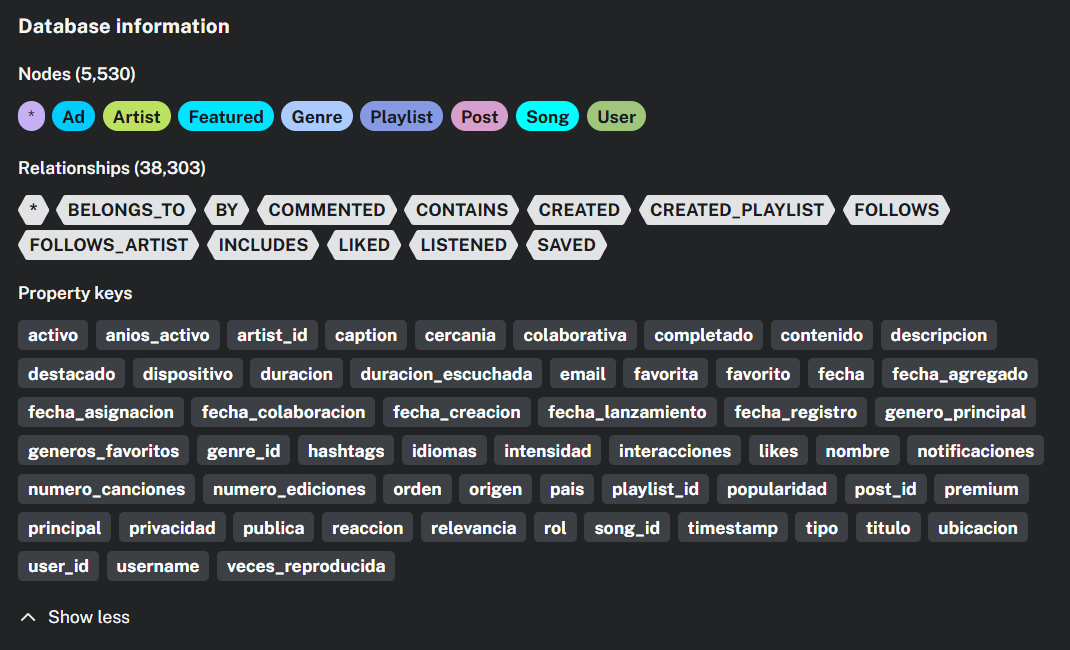